In [52]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [130]:
pi = np.pi

sim = Sim(use_complex=True)


sim.add_param('sqrtka_ext1', np.sqrt(10e6*2*pi)) # in MHz
sim.add_param('sqrtka_ext2', np.sqrt(0.1e6*2*pi)) # in MHz
sim.add_param('ka_int', 20e6*2*pi) # in MHz
sim.add_param('amplR',  1000)
sim.add_param('wa', 5.0e9*2*pi)
sim.add_paramsweep('wR', 4.5e9 * 2 * np.pi, 5.5e9 * 2 * np.pi, 101, is_excitation=True)
sim.add_param('rampR', 1e-9)
sim.add_param('startR', 5e-9)
sim.add_param('stopR', 200e-9)
sim.add_param('phaseR', 0)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')

sim.add_EOM('ain', Rpulse)

sim.add_EOM('a', '-1j*wa*a - ain*sqrtka_ext1 - (sqrtka_ext1**2 + sqrtka_ext2**2 + ka_int)/2*a')
sim.set_solve_type('decimate')

sim.specify_time(20, 500, d_factor=1)

sim.validate()

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


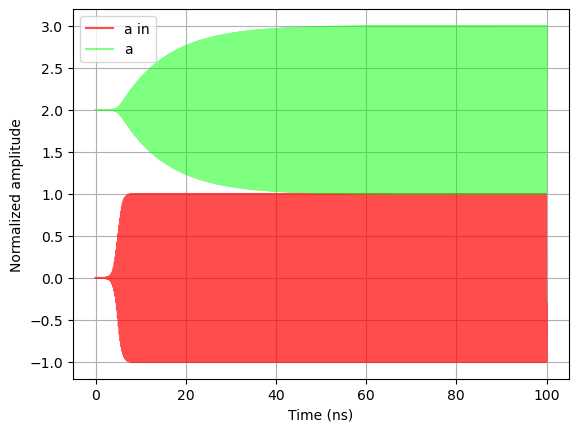

In [131]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='a')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [132]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [00:05<00:00, 1847.68it/s]

 
...finished GPU solve!


In [133]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

ain = Id[0,:]+1j*Qd[0,:]
a = Id[2,:]+1j*Qd[2,:]

aout1 = ain + sim.param_dict['sqrtka_ext1']*a
aout2 = ain*0.1 + sim.param_dict['sqrtka_ext2']*a

C:\Users\boris\AppData\Local\Temp\ipykernel_23736\1498122812.py:1: RuntimeWarning: invalid value encountered in divide
  S11 = (aout1/ain)[:,-1]
C:\Users\boris\AppData\Local\Temp\ipykernel_23736\1498122812.py:2: RuntimeWarning: invalid value encountered in divide
  S21 = (aout2/ain)[:,-1]


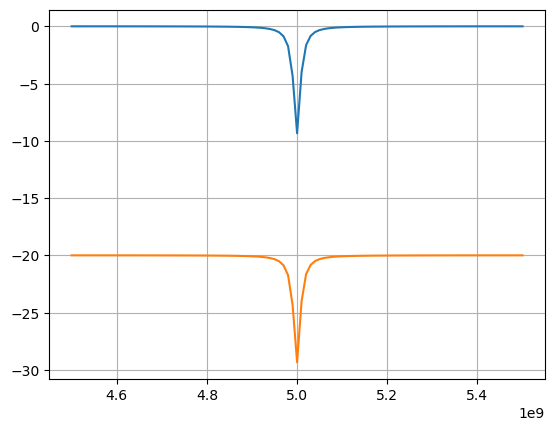

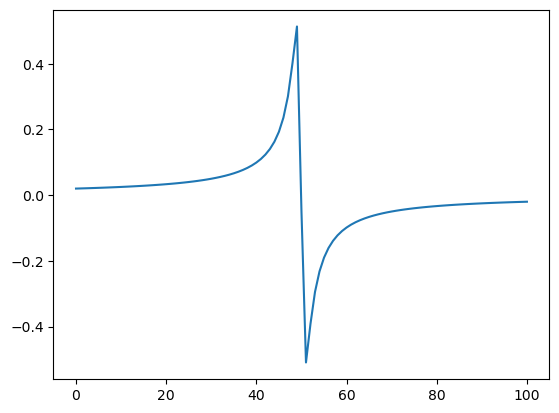

In [134]:
S11 = (aout1/ain)[:,-1]
S21 = (aout2/ain)[:,-1]

wR = sim.paramsweep_dict['wR']/(2*np.pi)

plt.clf()
plt.plot(wR, 10*np.log10(S11**2))
plt.plot(wR, 10*np.log10(S21**2))
plt.grid()
plt.show()

plt.plot(np.angle(S11))
plt.show()